# Differential Expression with Sample Variance

The natural next step after [Getting Started](./01_getting_started.ipynb).

With biological replicates, variation **between samples** of the same condition is often
larger than technical noise. Ignoring it inflates significance and hurts reproducibility.
Kompot builds a per-sample estimator, measures sample-to-sample covariance, and folds it
into the Mahalanobis distance — yielding conservative, replicate-aware calls. The
derivation is in the [paper](https://www.biorxiv.org/content/10.1101/2025.06.03.657769).

This dataset has **3 replicates per age group**.

In [1]:
%matplotlib inline

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import palantir
import pandas as pd
import scanpy as sc

import kompot

# Consistent, clean plotting style across the tutorial set
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["image.cmap"] = "Spectral_r"

In [2]:
DATA_PATH = "../data/murine_bone_marrow_aging.h5ad"
SAMPLE_COLUMN = "Replicate"             # biological-replicate identifiers
GROUPING_COLUMN = "Age"
CONDITIONS = ["Young", "Old"]
CELL_TYPE_COLUMN = "highres_celltype"
DIMENSIONALITY_REDUCTION = "DM_EigenVectors"
LAYER_FOR_EXPRESSION = "logged_counts"

## Load Data

In [3]:
adata = ad.read_h5ad(DATA_PATH)
palantir.utils.run_diffusion_maps(adata, pca_key="X_pca_harmony", n_components=40)
adata

AnnData object with n_obs × n_vars = 8090 × 16285
    obs: 'Compartment', 'Replicate', 'Age', 'Sample', 'Info', 'batch', 'doublet_score', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'leiden', 'phenograph', 'highres_celltype', 'midres_celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'hb', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'Age_colors', 'Compartment_colors', 'DMEigenValues', 'DM_EigenValues', 'Info_colors', 'README', 'Replicate_colors', 'Sample_colors', 'batch_colors', 'draw_graph', 'highres_celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'midres_celltype_colors', 'neighbors', 'pca', 'phase_colors', 'umap'
    obsm: 'AbCapture', 'DM_EigenVectors', 'HTO', 'X_draw_graph_fa', 'X_pca', 'X_pca_harmony', 'X_

Replicates per condition:

In [4]:
adata.obs.groupby([GROUPING_COLUMN, SAMPLE_COLUMN]).size().unstack(fill_value=0)

/tmp/ipykernel_651/3107917919.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby([GROUPING_COLUMN, SAMPLE_COLUMN]).size().unstack(fill_value=0)


Replicate,1,2,3
Age,,,
Mid,1035,1022,0
Old,1057,1019,1040
Young,944,1007,966


## Baseline: DE Without Sample Variance

Run standard DE first as the reference (`run_id=0`):

In [5]:
de_standard = kompot.de(
    adata,
    groupby=GROUPING_COLUMN,
    condition1=CONDITIONS[0],
    condition2=CONDITIONS[1],
    layer=LAYER_FOR_EXPRESSION,
    obsm_key=DIMENSIONALITY_REDUCTION,
    gp=kompot.GPSettings(batch_size=0),
)

[2026-07-11 01:30:39,288] [INFO    ] Condition 1 (Young): 2,917 cells


[2026-07-11 01:30:39,289] [INFO    ] Condition 2 (Old): 3,116 cells


[2026-07-11 01:30:43,908] [INFO    ] Fitting expression estimator for condition 1...


[2026-07-11 01:31:12,552] [INFO    ] Fitting expression estimator for condition 2...


[2026-07-11 01:32:15,129] [INFO    ] FDR analysis complete: 192/16285 genes significantly DE at FDR < 0.05


[2026-07-11 01:32:15,131] [INFO    ] Mahalanobis distance threshold for FDR < 0.05: 5.8215


[2026-07-11 01:32:21,822] [INFO    ] This run will have `run_id=0`.


## DE With Sample Variance

Add `sample_col`. Kompot now computes gene-specific covariance matrices, which costs
memory, so we use three levers:

1. **subset to top genes** from the standard run,
2. **store arrays on disk** (`StorageSettings`),
3. **skip FDR** (`null_genes=0`) — not yet calibrated for sample variance.

Check the plan first with `dry_run=True`:

In [6]:
c1, c2 = CONDITIONS
mahal = f"kompot_de_{c1}_to_{c2}_mahalanobis"
top_genes = adata.var.sort_values(mahal, ascending=False).head(50).index

plan = kompot.de(
    adata,
    groupby=GROUPING_COLUMN,
    condition1=c1, condition2=c2,
    layer=LAYER_FOR_EXPRESSION,
    obsm_key=DIMENSIONALITY_REDUCTION,
    sample_col=SAMPLE_COLUMN,
    genes=top_genes,
    gp=kompot.GPSettings(batch_size=0),
    storage=kompot.StorageSettings(store_arrays_on_disk=True),
    fdr=kompot.FDRSettings(null_genes=0),
    dry_run=True,
)

RESOURCE USAGE PLAN

System Resources:
  Memory: 631.87 GB available (of 754.57 GB total)
  Disk:   361.54 GB available at /tmp

Total Requirements:
  Memory: 1.29 GB (0% of available)
  Disk:   18.63 GB (5% of available)

Memory Allocations:
  • Mellon precision matrix L (condition 1, 2,917/3,116 cells) (np.int64(2917), np.int64(2917)): 64.92 MB
  • Mellon precision matrix L (condition 2, 2,917/3,116 cells) (np.int64(3116), np.int64(3116)): 74.08 MB
  • Smoothed expression (condition 1) (8090, 50): 3.09 MB → adata.layers['kompot_de_Young_smoothed']
  • Smoothed expression (condition 2) (8090, 50): 3.09 MB → adata.layers['kompot_de_Old_smoothed']
  • Fold change (8090, 50): 3.09 MB → adata.layers['kompot_de_Young_to_Old_fold_change']
  • Standard deviation (condition 1) (8090, 50): 3.09 MB → adata.layers['kompot_de_Young_std']
  • Standard deviation (condition 2) (8090, 50): 3.09 MB → adata.layers['kompot_de_Old_std']
  • Temporary matrices during predictions (batch_size=0) (8090, 5000

If the plan fits, run it (`run_id=1`):

In [7]:
de_sample_var = kompot.de(
    adata,
    groupby=GROUPING_COLUMN,
    condition1=c1, condition2=c2,
    layer=LAYER_FOR_EXPRESSION,
    obsm_key=DIMENSIONALITY_REDUCTION,
    sample_col=SAMPLE_COLUMN,
    genes=top_genes,
    gp=kompot.GPSettings(batch_size=0),
    storage=kompot.StorageSettings(store_arrays_on_disk=True),
    fdr=kompot.FDRSettings(null_genes=0),
)

[2026-07-11 01:32:22,345] [INFO    ] Differential expression results with result_key='kompot_de' already exist in the dataset. Previous run was at 2026-07-11T01:32:21.770524 comparing Young to Old. Fields that will be overwritten: var.kompot_de_Young_to_Old_mean_lfc, layers.kompot_de_Young_smoothed, layers.kompot_de_Old_smoothed, layers.kompot_de_Young_to_Old_fold_change. Note: Only fields NOT affected by sample variance (like mean_log_fold_change, smoothed data, fold_change) will be overwritten since they don't use the sample variance suffix. These results will likely be identical if other parameters haven't changed. This is a partial rerun with sample variance added to a previous analysis with matching parameters. Set overwrite=False to prevent overwriting or overwrite=True to silence this message.


[2026-07-11 01:32:22,347] [INFO    ] Condition 1 (Young): 2,917 cells


[2026-07-11 01:32:22,348] [INFO    ] Condition 2 (Old): 3,116 cells


[2026-07-11 01:32:22,905] [INFO    ] Using sample column 'Replicate' for sample variance estimation


[2026-07-11 01:32:22,907] [INFO    ] Found 3 unique sample(s) in condition 1


...

Computing Mahalanobis distances:   0%|          | 0/50 [00:00<?, ?it/s]

[2026-07-11 01:36:29,284] [INFO    ] Updating 50 genes (0.3% of total) in existing sparse layers: kompot_de_Young_std, kompot_de_Old_std. Temporarily converting CSR->LIL->CSR to avoid slow per-gene modifications.


[2026-07-11 01:36:30,134] [INFO    ] This run will have `run_id=1`.


[2026-07-11 01:36:30,169] [INFO    ] Removed temporary storage directory /tmp/kompot_arrays_014f3181_cuguwm9t


[2026-07-11 01:36:30,284] [INFO    ] Removed temporary storage directory /tmp/kompot_arrays_9ecd22cb_pt9wuuyh


## Compare

Sample-variance results carry a `_sample_var` suffix. Fold changes are unchanged; only
significance shifts:

In [8]:
cols = [
    f"kompot_de_{c1}_to_{c2}_mean_lfc",
    f"kompot_de_{c1}_to_{c2}_mahalanobis",
    f"kompot_de_{c1}_to_{c2}_mahalanobis_sample_var",
]
comparison = adata.var.loc[top_genes, cols].sort_values(cols[1], ascending=False)
comparison.head(20)

,kompot_de_Young_to_Old_mean_lfc,kompot_de_Young_to_Old_mahalanobis,kompot_de_Young_to_Old_mahalanobis_sample_var
H2-Q7,0.371810,15.224920,10.043567
Cd74,0.105968,12.781286,10.791307
H2-Aa,0.142574,12.641082,8.861583
H2-Ab1,0.153822,12.307942,8.316963
Igkc,0.016244,11.416240,8.666152
H2-Eb1,0.123908,11.371004,7.737303
AW112010,0.238251,11.366238,7.150069
S100a9,-0.051261,10.385744,9.975386
Ifitm3,0.110643,10.134062,8.776124
S100a8,-0.049699,10.089391,9.740630


Genes that lose significance are the ones that vary most across replicates. Volcano plots, standard vs. sample-variance:

[2026-07-11 01:36:30,400] [INFO    ] Found DE run info for run_id=0


[2026-07-11 01:36:30,401] [INFO    ] Found mean_lfc_key='kompot_de_Young_to_Old_mean_lfc' from run info


[2026-07-11 01:36:30,402] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Old_mahalanobis' from run info


[2026-07-11 01:36:30,404] [WARNING ] Field 'kompot_de_Young_to_Old_mean_lfc' has been written by 2 different runs, indicating potential overwrites


[2026-07-11 01:36:30,405] [WARNING ] Field 'kompot_de_Young_to_Old_mahalanobis' was last written by run 0, but current context expects run 1. The field may have been overwritten.


...

[2026-07-11 01:36:30,407] [WARNING ] Field inference completed with 2 warnings


[2026-07-11 01:36:30,409] [INFO    ] Using DE run 0: comparing Young to Old


[2026-07-11 01:36:30,423] [INFO    ] Using data columns from var - lfc: 'kompot_de_Young_to_Old_mean_lfc', score: 'kompot_de_Young_to_Old_mahalanobis'


[2026-07-11 01:36:30,428] [INFO    ] Highlighting 192 genes marked as DE (109 up, 83 down)


[2026-07-11 01:36:30,441] [INFO    ] Labeling top 10 genes by score


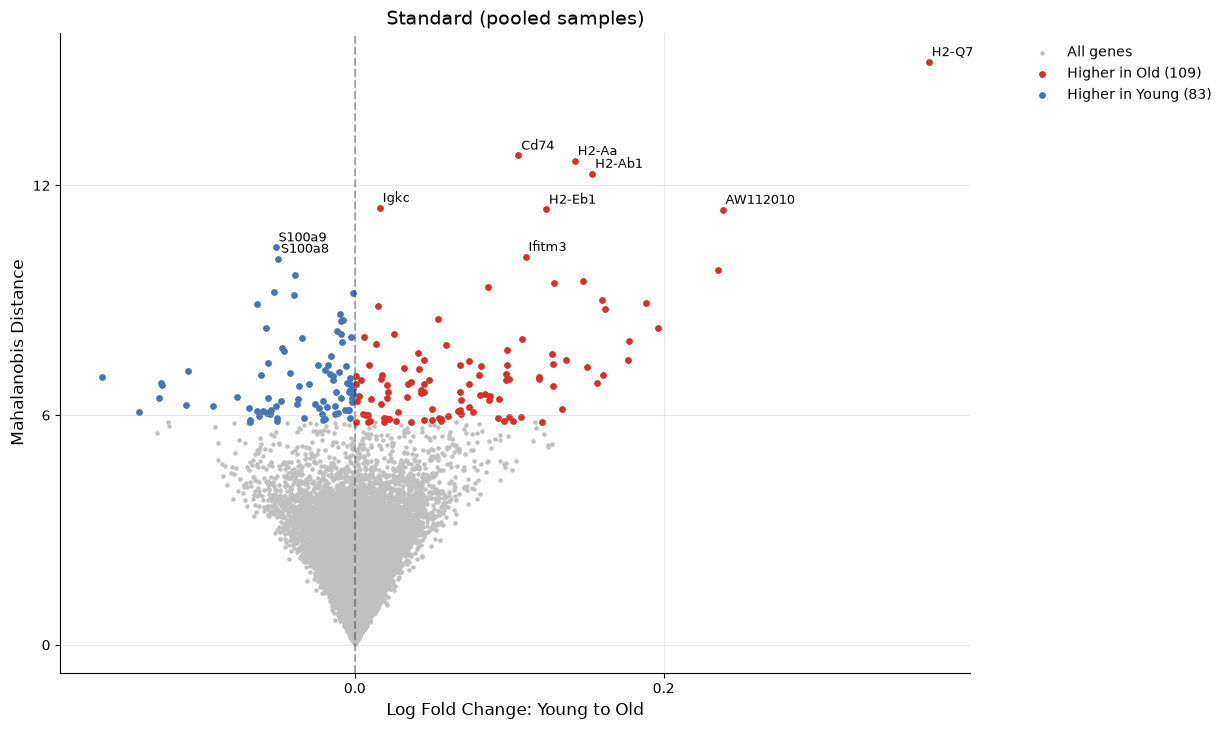

In [9]:
kompot.plot.volcano_de(adata, run_id=0, title="Standard (pooled samples)")

[2026-07-11 01:36:30,748] [INFO    ] Found DE run info for run_id=1


[2026-07-11 01:36:30,749] [INFO    ] Found mean_lfc_key='kompot_de_Young_to_Old_mean_lfc' from run info


[2026-07-11 01:36:30,749] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Old_mahalanobis_sample_var' from run info


[2026-07-11 01:36:30,752] [WARNING ] Field 'kompot_de_Young_to_Old_mean_lfc' has been written by 2 different runs, indicating potential overwrites


[2026-07-11 01:36:30,754] [INFO    ] Successfully inferred fields: {'mean_lfc_key': 'kompot_de_Young_to_Old_mean_lfc', 'mahalanobis_key': 'kompot_de_Young_to_Old_mahalanobis_sample_var'}


[2026-07-11 01:36:30,754] [WARNING ] Field inference completed with 1 warnings


[2026-07-11 01:36:30,755] [INFO    ] Using DE run 1: comparing Young to Old


[2026-07-11 01:36:30,767] [INFO    ] Using data columns from var - lfc: 'kompot_de_Young_to_Old_mean_lfc', score: 'kompot_de_Young_to_Old_mahalanobis_sample_var'


[2026-07-11 01:36:30,770] [INFO    ] Highlighting top 40 genes by kompot_de_Young_to_Old_mahalanobis_sample_var


[2026-07-11 01:36:30,779] [INFO    ] Labeling top 20 genes by score


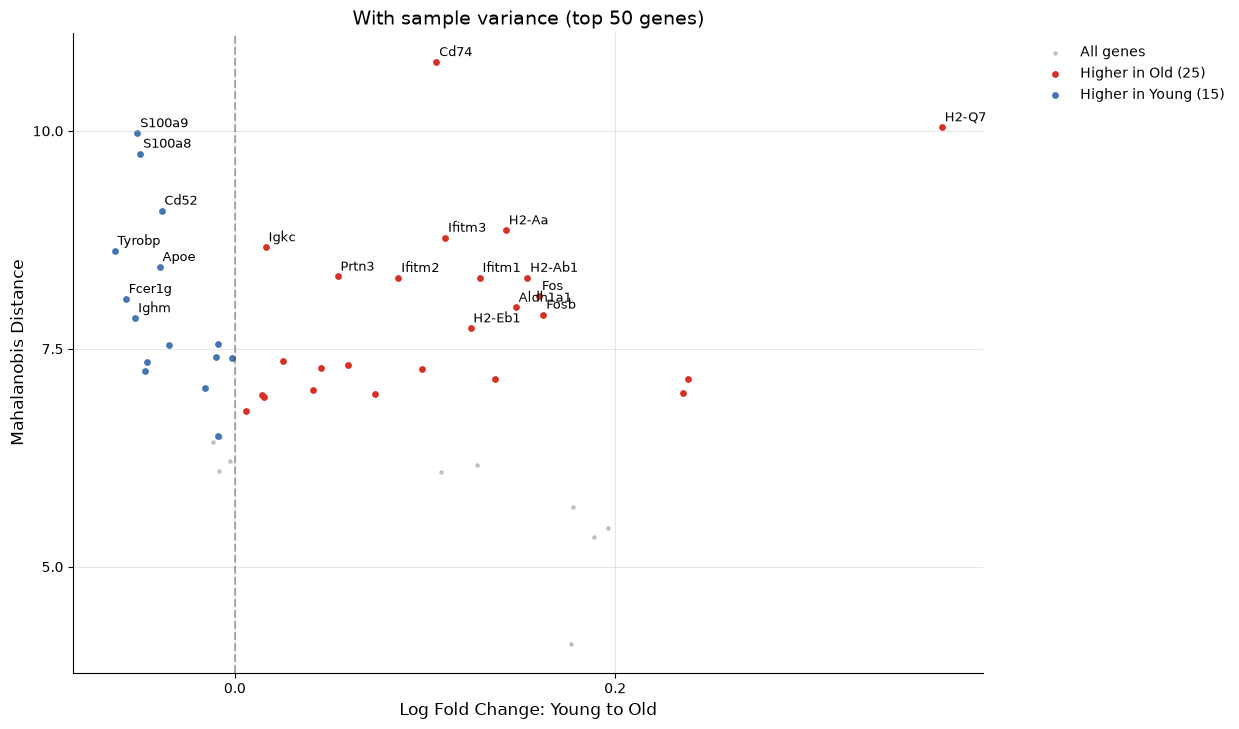

In [10]:
kompot.plot.volcano_de(
    adata, run_id=1,
    n_top_genes=40,          # no FDR threshold here (null_genes=0)
    gene_labels=20,
    title="With sample variance (top 50 genes)",
)

## Sample-to-Sample Variability

Rank genes by how much significance they lose, then compare their expression between two
replicates of the *same* condition:

In [11]:
comparison["decrease"] = comparison[cols[1]] - comparison[cols[2]]
variable_genes = comparison.nlargest(20, "decrease").index
list(variable_genes)

['H2-Q7',
 'AW112010',
 'H2-Ab1',
 'H2-Aa',
 'H2-Eb1',
 'Gm47283',
 'Ifi27',
 'Cirbp',
 'H2-Q6',
 'Igkc',
 'H2-K1',
 'Trbc2',
 'Cd74',
 'Lilr4b',
 'Cd3g',
 'Ms4a4b',
 'Ebf1',
 'Cd79a',
 'Ly6d',
 'Cd3d']

[2026-07-11 01:36:31,110] [INFO    ] Inferred layer='logged_counts' from run information


[2026-07-11 01:36:31,111] [INFO    ] Creating split heatmap with 20 genes/features


[2026-07-11 01:36:31,112] [INFO    ] Using display names: 'Replicate 1' for condition1, 'Replicate 3' for condition2


[2026-07-11 01:36:31,113] [INFO    ] Using expression data from layer: 'logged_counts'


[2026-07-11 01:36:31,236] [INFO    ] Applying gene-wise z-scoring (standard_scale='var')


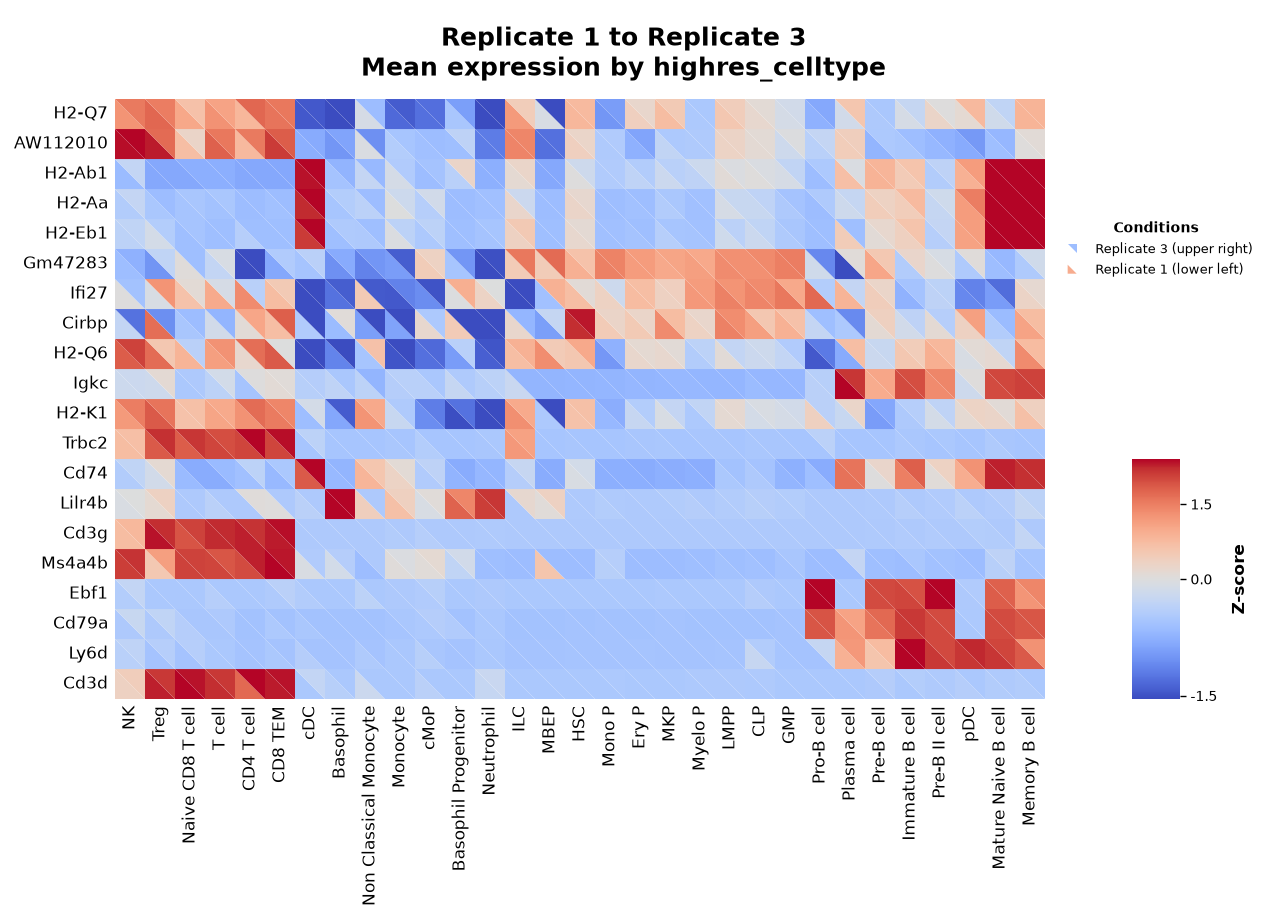

In [12]:
kompot.plot.heatmap(
    adata,
    genes=variable_genes,
    groupby=CELL_TYPE_COLUMN,
    condition_column=SAMPLE_COLUMN,
    condition1="1", condition1_name="Replicate 1",
    condition2="3", condition2_name="Replicate 3",
    vmin="p2", vmax="p98",
    cluster_rows=False,
)

These genes differ substantially **between replicates** of the same age — exactly why their significance drops under sample variance.

## Best Practices

**Use sample variance when** you have ≥3 replicates per condition and want conservative,
reproducible calls. For DE specifically: always `dry_run` first, subset to top genes,
store arrays on disk, and set `null_genes=0` unless you need FDR.

Effect sizes stay identical; only confidence changes. Genes that survive the correction
are the robust, replicate-consistent signals.

In [13]:
kompot.cleanup(adata)
adata.write_h5ad("../data/murine_bone_marrow_aging_with_sample_variance.h5ad")

[2026-07-11 01:36:33,094] [INFO    ] Cleaning up all 2 run(s)


[2026-07-11 01:36:33,248] [INFO    ] Cleaned up 3 field(s) from run 0:


[2026-07-11 01:36:33,249] [INFO    ]   layers (3 field(s)):


[2026-07-11 01:36:33,250] [INFO    ]     - kompot_de_Young_smoothed


[2026-07-11 01:36:33,250] [INFO    ]     - kompot_de_Old_smoothed


...

[2026-07-11 01:36:33,255] [INFO    ] Cleaned up 2 field(s) from run 1:


[2026-07-11 01:36:33,256] [INFO    ]   layers (2 field(s)):


[2026-07-11 01:36:33,256] [INFO    ]     - kompot_de_Young_std


[2026-07-11 01:36:33,257] [INFO    ]     - kompot_de_Old_std


[2026-07-11 01:36:33,258] [INFO    ] Total: Cleaned up 5 field(s) across 2 run(s)


## Where to go deeper

- **[Getting Started](./01_getting_started.ipynb)** · **[Advanced DE options](./02_differential_expression_detailed.ipynb)**
- **[Differential abundance](./04_differential_abundance.ipynb)** — including its own sample-variance treatment.
- **[Paper](https://www.biorxiv.org/content/10.1101/2025.06.03.657769)** ·
  **[Documentation](https://kompot.readthedocs.io)**